# Chicago Crime Data
### Chicago Data Portal: Crimes 2001 - 2022
#### Includes:
type of crime, exact date/time, lat/long, district/ward, whether there was an arrest, etc.


**Import Libraries**

In [82]:
import pandas as pd
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

import pmdarima as pm

**Load and Combine the Raw Data**

Open the `Chicago_Crime_2001-2022.zip` archive, list its contents, identify all CSV files inside it, read each one into a DataFrame, and concatenate them all into a single combined DataFrame `df`. Print the resulting shape, first rows, and column names.

In [20]:
zip_path = r"C:\Users\RaNia PC\Desktop\Axsos\Chicago_Crime_2001-2022.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    files_in_zip = z.namelist()

print("Number of files in ZIP:", len(files_in_zip))
print("\nFirst 20 files:")
print(files_in_zip[:20])
csv_files = [
    file for file in files_in_zip
    if file.lower().endswith(".csv")
]

print("\nNumber of CSV files:", len(csv_files))
print("\nCSV files:")
print(csv_files[:20])

dfs = []

with zipfile.ZipFile(zip_path, "r") as z:

    for file in csv_files:
        print("Reading:", file)

        with z.open(file) as f:
            temp = pd.read_csv(f)

        dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)
print("\nFinal DataFrame shape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumns:")
print(df.columns.tolist())

Number of files in ZIP: 23

First 20 files:
['Data/Chicago-Crime_2001.csv', 'Data/Chicago-Crime_2002.csv', 'Data/Chicago-Crime_2003.csv', 'Data/Chicago-Crime_2004.csv', 'Data/Chicago-Crime_2005.csv', 'Data/Chicago-Crime_2006.csv', 'Data/Chicago-Crime_2007.csv', 'Data/Chicago-Crime_2008.csv', 'Data/Chicago-Crime_2009.csv', 'Data/Chicago-Crime_2010.csv', 'Data/Chicago-Crime_2011.csv', 'Data/Chicago-Crime_2012.csv', 'Data/Chicago-Crime_2013.csv', 'Data/Chicago-Crime_2014.csv', 'Data/Chicago-Crime_2015.csv', 'Data/Chicago-Crime_2016.csv', 'Data/Chicago-Crime_2017.csv', 'Data/Chicago-Crime_2018.csv', 'Data/Chicago-Crime_2019.csv', 'Data/Chicago-Crime_2020.csv']

Number of CSV files: 22

CSV files:
['Data/Chicago-Crime_2001.csv', 'Data/Chicago-Crime_2002.csv', 'Data/Chicago-Crime_2003.csv', 'Data/Chicago-Crime_2004.csv', 'Data/Chicago-Crime_2005.csv', 'Data/Chicago-Crime_2006.csv', 'Data/Chicago-Crime_2007.csv', 'Data/Chicago-Crime_2008.csv', 'Data/Chicago-Crime_2009.csv', 'Data/Chicago-Crim

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
0,1326041,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE,False,False,1624,16.0,NaN,41.957850,-87.749185
1,1319931,01/01/2001 01:00:00 PM,BATTERY,SIMPLE,RESIDENCE,False,True,825,8.0,NaN,41.783892,-87.684841
2,1324743,01/01/2001 01:00:00 PM,GAMBLING,ILLEGAL ILL LOTTERY,STREET,True,False,313,3.0,NaN,41.780412,-87.611970
3,1310717,01/01/2001 01:00:00 AM,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2424,24.0,NaN,42.012391,-87.678032
4,1318099,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE PORCH/HALLWAY,False,True,214,2.0,NaN,41.819538,-87.620020



Columns:
['ID', 'Date', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Latitude', 'Longitude']


**Dates**

Convert the `Date` column to proper `datetime` objects, coercing any unparseable values to `NaT`.

In [22]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [23]:
df = df.dropna(subset=["Date"])

In [24]:
df = df.set_index("Date").sort_index()

In [25]:
df.head()
df.index

DatetimeIndex(['2001-01-01 00:00:00', '2001-01-01 00:00:00',
               '2001-01-01 00:00:00', '2001-01-01 00:00:00',
               '2001-01-01 00:00:00', '2001-01-01 00:00:00',
               '2001-01-01 00:00:00', '2001-01-01 00:00:00',
               '2001-01-01 00:00:00', '2001-01-01 00:00:00',
               ...
               '2022-12-31 23:45:00', '2022-12-31 23:45:00',
               '2022-12-31 23:45:00', '2022-12-31 23:45:00',
               '2022-12-31 23:45:00', '2022-12-31 23:47:00',
               '2022-12-31 23:47:00', '2022-12-31 23:50:00',
               '2022-12-31 23:50:00', '2022-12-31 23:55:00'],
              dtype='datetime64[us]', name='Date', length=7713109, freq=None)

Which district had the most crimes in 2022?

**Import Matplotlib**
Import `matplotlib.pyplot` for the plots used in this section.

In [32]:
import matplotlib.pyplot as plt


**Yearly Crime Totals**
Resample the data to compute the total number of crimes per year.

In [34]:
yearly_crimes = df.resample("YS").size()

yearly_crimes

Date
2001-01-01    485886
2002-01-01    486807
2003-01-01    475985
2004-01-01    469422
2005-01-01    453773
2006-01-01    448179
2007-01-01    437087
2008-01-01    427183
2009-01-01    392827
2010-01-01    370513
2011-01-01    351993
2012-01-01    336319
2013-01-01    307536
2014-01-01    275789
2015-01-01    264787
2016-01-01    269823
2017-01-01    269100
2018-01-01    268899
2019-01-01    261325
2020-01-01    212194
2021-01-01    208824
2022-01-01    238858
Freq: YS-JAN, dtype: int64

**Simplify the Year Index**
Replace the yearly timestamp index with plain year integers for readability.

In [35]:
yearly_crimes.index = yearly_crimes.index.year

yearly_crimes

Date
2001    485886
2002    486807
2003    475985
2004    469422
2005    453773
2006    448179
2007    437087
2008    427183
2009    392827
2010    370513
2011    351993
2012    336319
2013    307536
2014    275789
2015    264787
2016    269823
2017    269100
2018    268899
2019    261325
2020    212194
2021    208824
2022    238858
dtype: int64

**Plot Crimes Across the Years**:

Line chart showing how total crime volume changed year over year across the full 2001–2022 period.

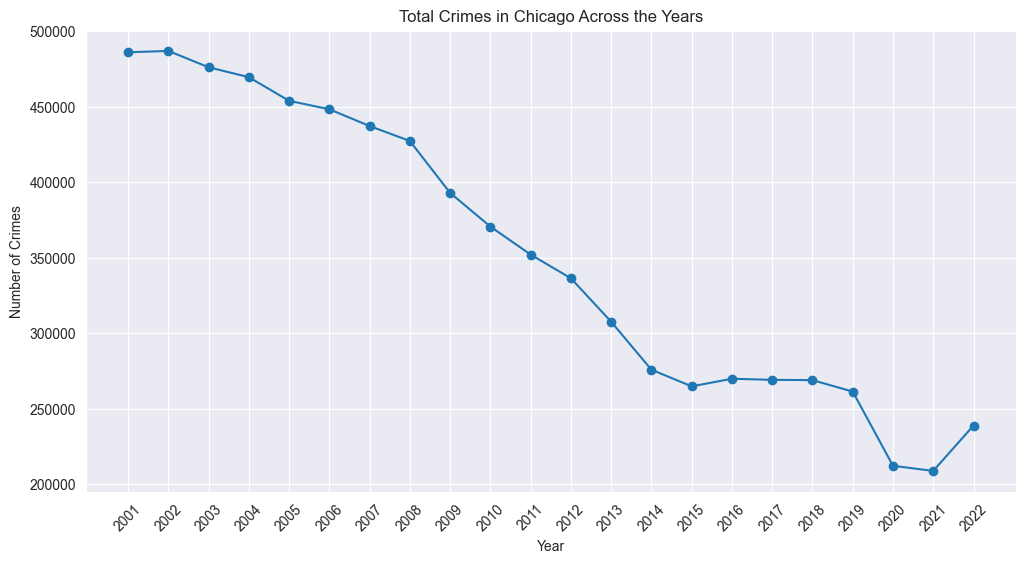

In [36]:
plt.figure(figsize=(12, 6))

plt.plot(yearly_crimes.index, yearly_crimes.values, marker="o")

plt.title("Total Crimes in Chicago Across the Years")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")

plt.xticks(yearly_crimes.index, rotation=45)
plt.grid(True)

plt.show()

**Crime Counts by Year and Type**:

Build a cross-tabulation (`crime_by_year`) showing the count of each crime type (`Primary Type`) per year.

In [38]:
crime_by_year = pd.crosstab(
    df.index.year,
    df["Primary Type"]
)

crime_by_year.head()

Primary Type,ARSON,ASSAULT,BATTERY,BURGLARY,CONCEALED CARRY LICENSE VIOLATION,CRIM SEXUAL ASSAULT,CRIMINAL DAMAGE,CRIMINAL SEXUAL ASSAULT,CRIMINAL TRESPASS,DECEPTIVE PRACTICE,...,OTHER OFFENSE,PROSTITUTION,PUBLIC INDECENCY,PUBLIC PEACE VIOLATION,RITUALISM,ROBBERY,SEX OFFENSE,STALKING,THEFT,WEAPONS VIOLATION
row_0,,,,,,,,,,,,,,,,,,,,,
2001,1011,31384,93461,26014,1,1779,55859,29,13241,14949,...,29662,6026,9,2750,8,18441,2239,204,99277,4277
2002,1032,31523,94153,25623,0,1807,55941,27,13880,13732,...,32600,6408,8,2457,2,18523,2173,200,98332,4281
2003,955,29477,88380,25157,0,1571,55011,41,14807,13459,...,31148,6214,6,2430,2,17332,2078,247,98876,4211
2004,778,28850,87136,24564,0,1538,53164,42,15913,13255,...,29532,7476,9,2495,1,15978,1805,215,95463,4298
2005,691,27067,83964,25503,0,1521,54548,37,16655,13590,...,28028,6124,4,2730,2,16047,1817,192,85684,4106


In [39]:
import numpy as np

**Compute Trend Slope per Crime Type**:

Fit a simple linear trend (`np.polyfit`) to each crime type's yearly counts and store the resulting slope, which indicates whether that crime type is increasing or decreasing over time.

In [40]:
crime_trends = {}

x = np.arange(len(crime_by_year))

for crime in crime_by_year.columns:
    y = crime_by_year[crime].values

    slope, intercept = np.polyfit(x, y, 1)

    crime_trends[crime] = slope

**Rank Crime Types by Trend**:

Build a DataFrame of crime types and their trend slopes, sorted from the strongest increasing trend to the strongest decreasing trend.

In [41]:
crime_trends_df = pd.DataFrame(
    list(crime_trends.items()),
    columns=["Primary Type", "Trend Slope"]
)

crime_trends_df = crime_trends_df.sort_values(
    "Trend Slope",
    ascending=False
)

crime_trends_df

,Primary Type,Trend Slope
9,DECEPTIVE PRACTICE,276.701299
35,WEAPONS VIOLATION,170.457369
7,CRIMINAL SEXUAL ASSAULT,54.194805
14,INTERFERENCE WITH PUBLIC OFFICER,24.849238
4,CONCEALED CARRY LICENSE VIOLATION,9.083569
12,HOMICIDE,8.574816
33,STALKING,4.075663
23,OBSCENITY,2.709204
21,NON-CRIMINAL,0.993224
13,HUMAN TRAFFICKING,0.731790


**Overall Crime Trend**:
Fit a linear trend to the total yearly crime counts to determine whether overall crime is increasing or decreasing.

In [42]:
increasing_overall = slope > 0
x_overall = np.arange(len(yearly_crimes))
y_overall = yearly_crimes.values

overall_slope, overall_intercept = np.polyfit(
    x_overall,
    y_overall,
    1
)

print("Overall trend slope:", overall_slope)

Overall trend slope: -14613.405420666282


**Identify Crimes Moving Against the Overall Trend**

Select the crime types whose individual trend direction is opposite to the overall crime trend.

In [43]:
if overall_slope > 0:
    opposite_crimes = crime_trends_df[
        crime_trends_df["Trend Slope"] < 0
    ]

elif overall_slope < 0:
    opposite_crimes = crime_trends_df[
        crime_trends_df["Trend Slope"] > 0
    ]

else:
    opposite_crimes = pd.DataFrame()

**Display Opposite-Trend Crimes**:

Show the crime types identified as moving against the overall trend.

In [44]:
opposite_crimes

,Primary Type,Trend Slope
9,DECEPTIVE PRACTICE,276.701299
35,WEAPONS VIOLATION,170.457369
7,CRIMINAL SEXUAL ASSAULT,54.194805
14,INTERFERENCE WITH PUBLIC OFFICER,24.849238
4,CONCEALED CARRY LICENSE VIOLATION,9.083569
12,HOMICIDE,8.574816
33,STALKING,4.075663
23,OBSCENITY,2.709204
21,NON-CRIMINAL,0.993224
13,HUMAN TRAFFICKING,0.731790


**Top 5 Opposite-Trend Crimes**:

Take the 5 crime types with the strongest trend opposite to the overall pattern.

In [45]:
top_opposite = opposite_crimes.head(5)

top_opposite

,Primary Type,Trend Slope
9,DECEPTIVE PRACTICE,276.701299
35,WEAPONS VIOLATION,170.457369
7,CRIMINAL SEXUAL ASSAULT,54.194805
14,INTERFERENCE WITH PUBLIC OFFICER,24.849238
4,CONCEALED CARRY LICENSE VIOLATION,9.083569


**Plot Opposite-Trend Slopes**:

Horizontal bar chart of the trend slopes for the top 5 crime types moving against the overall trend.

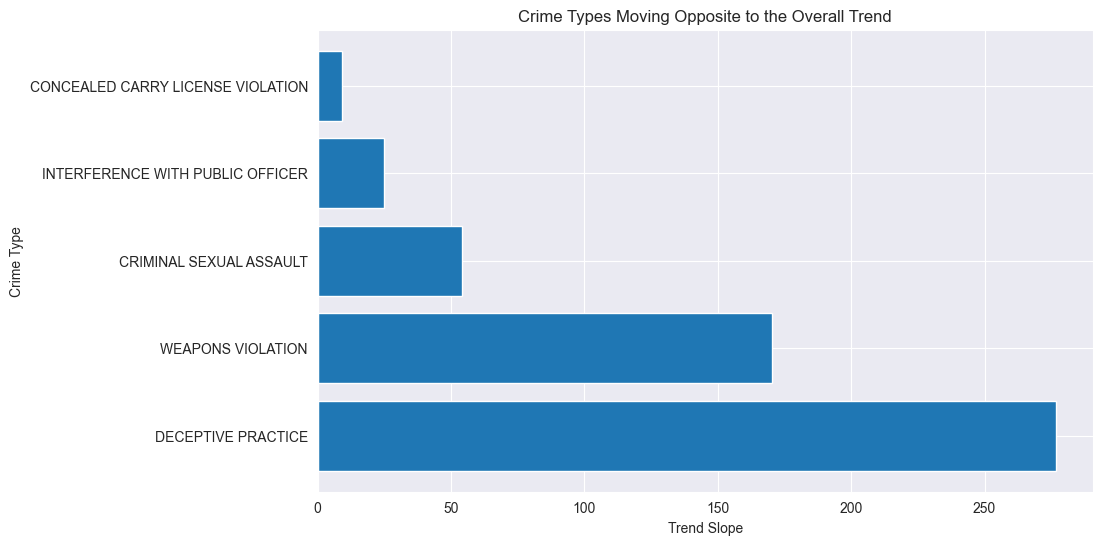

In [46]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_opposite["Primary Type"],
    top_opposite["Trend Slope"]
)

plt.title("Crime Types Moving Opposite to the Overall Trend")
plt.xlabel("Trend Slope")
plt.ylabel("Crime Type")

plt.show()

**Plot Yearly Counts for Opposite-Trend Crimes**:
Line chart showing the yearly crime counts for each of the top 5 opposite-trend crime types.

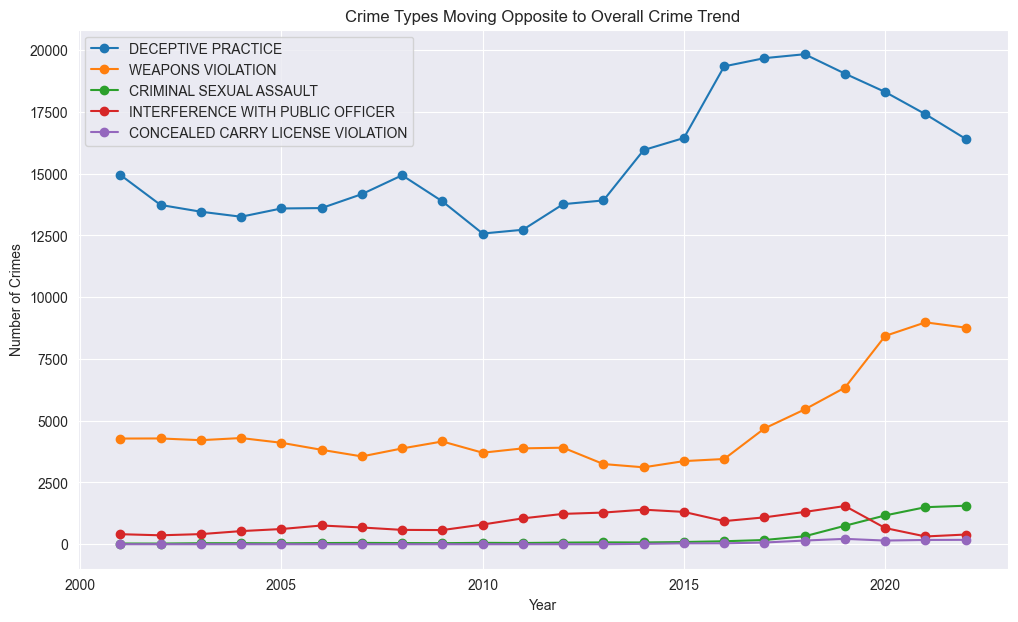

In [47]:
top_crimes = opposite_crimes.head(5)["Primary Type"]

plt.figure(figsize=(12, 7))

for crime in top_crimes:
    plt.plot(
        crime_by_year.index,
        crime_by_year[crime],
        marker="o",
        label=crime
    )

plt.title("Crime Types Moving Opposite to Overall Crime Trend")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")

plt.legend()
plt.grid(True)

plt.show()

Comparing AM vs. PM Rush Hour

**Extract Hour of Day**

Add an `Hour` column derived from the datetime index, used for the rush-hour comparison below.

In [50]:
df["Hour"] = df.index.hour

**Preview Hour and Crime Type**

Quick look at the `Hour` and `Primary Type` columns together.

In [51]:
df[["Hour", "Primary Type"]].head()

,Hour,Primary Type
Date,,
2001-01-01,0,THEFT
2001-01-01,0,THEFT
2001-01-01,0,OFFENSE INVOLVING CHILDREN
2001-01-01,0,THEFT
2001-01-01,0,SEX OFFENSE


**Define Rush Hour Windows**

Split the data into an AM rush hour subset (7–9 AM) and a PM rush hour subset (4–6 PM).

In [52]:
am_rush = df[(df["Hour"] >= 7) & (df["Hour"] < 10)]

pm_rush = df[(df["Hour"] >= 16) & (df["Hour"] < 19)]

**Count Rush Hour Crimes**

Count the total number of crimes recorded during each rush hour window.

In [53]:
am_count = len(am_rush)
pm_count = len(pm_rush)

print("AM Rush Hour:", am_count)
print("PM Rush Hour:", pm_count)

AM Rush Hour: 770651
PM Rush Hour: 1206353


**Compare Rush Hour Totals**
Print which rush hour period has more recorded crimes.

In [54]:
if am_count > pm_count:
    print("Crimes are more common during AM Rush Hour.")
elif pm_count > am_count:
    print("Crimes are more common during PM Rush Hour.")
else:
    print("Crime counts are equal.")

Crimes are more common during PM Rush Hour.


**Plot AM vs PM Rush Hour Volume**

Bar chart comparing total crime counts during AM rush hour versus PM rush hour.

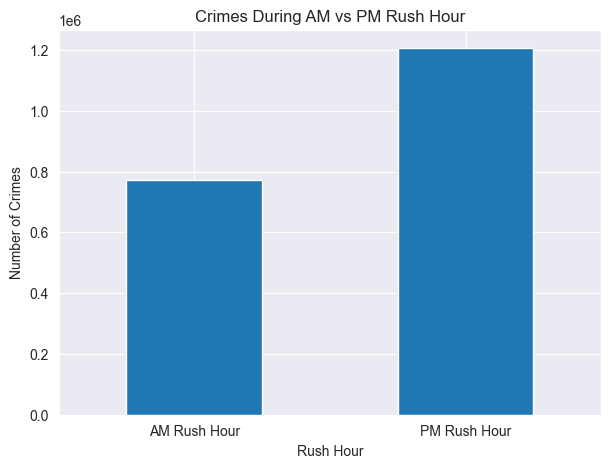

In [55]:
rush_hour_counts = pd.Series({
    "AM Rush Hour": am_count,
    "PM Rush Hour": pm_count
})

plt.figure(figsize=(7, 5))

rush_hour_counts.plot(kind="bar")

plt.title("Crimes During AM vs PM Rush Hour")
plt.xlabel("Rush Hour")
plt.ylabel("Number of Crimes")

plt.xticks(rotation=0)
plt.show()

Top 5 crimes during AM Rush Hour

**Top 5 Crime Types — AM Rush Hour**
Count the most frequent crime types occurring during the AM rush hour window.

In [56]:
am_top5 = am_rush["Primary Type"].value_counts().head(5)

am_top5

Primary Type
THEFT              185239
BATTERY            108199
CRIMINAL DAMAGE     81281
BURGLARY            73999
OTHER OFFENSE       62453
Name: count, dtype: int64

**Plot Top 5 AM Rush Hour Crimes**
Horizontal bar chart of the top 5 crime types during AM rush hour.

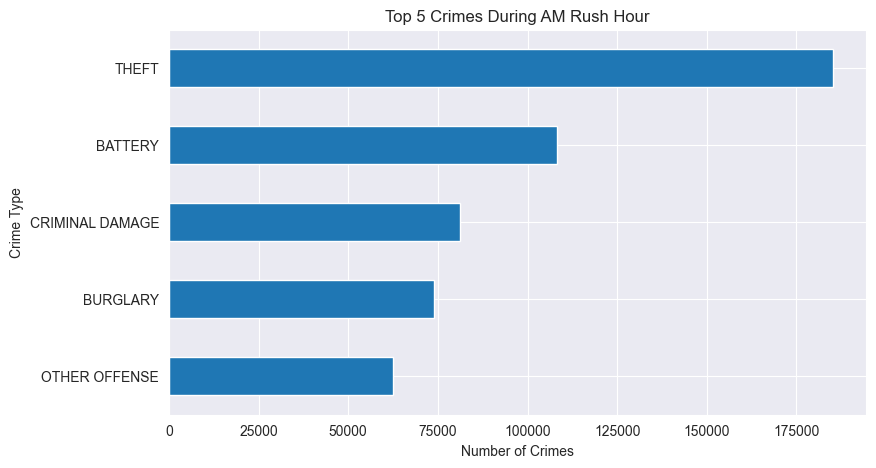

In [57]:
plt.figure(figsize=(9, 5))

am_top5.sort_values().plot(kind="barh")

plt.title("Top 5 Crimes During AM Rush Hour")
plt.xlabel("Number of Crimes")
plt.ylabel("Crime Type")

plt.show()

**Top 5 Crime Types — PM Rush Hour**
Count the most frequent crime types occurring during the PM rush hour window.

In [58]:
pm_top5 = pm_rush["Primary Type"].value_counts().head(5)

pm_top5

Primary Type
THEFT              293514
BATTERY            213002
CRIMINAL DAMAGE    134101
NARCOTICS          103032
ASSAULT             89600
Name: count, dtype: int64

**Plot Top 5 PM Rush Hour Crimes**
Horizontal bar chart of the top 5 crime types during PM rush hour.

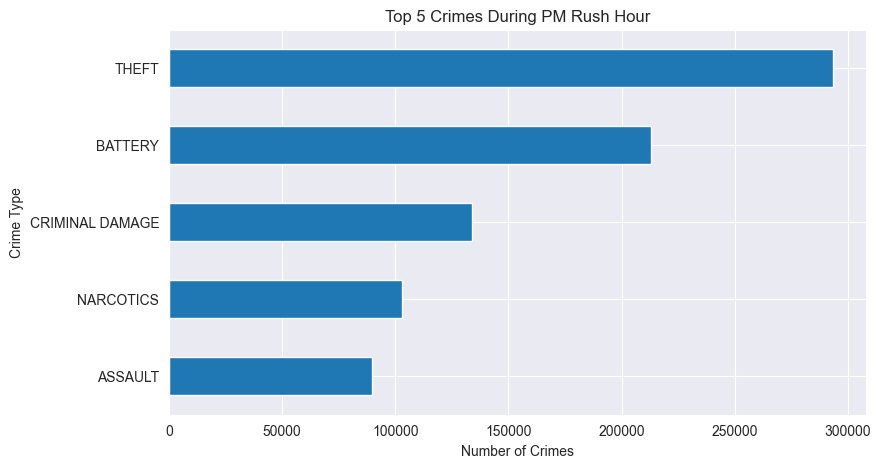

In [59]:
plt.figure(figsize=(9, 5))

pm_top5.sort_values().plot(kind="barh")

plt.title("Top 5 Crimes During PM Rush Hour")
plt.xlabel("Number of Crimes")
plt.ylabel("Crime Type")

plt.show()

**Motor Vehicle Theft: AM vs PM**
Count how many motor vehicle thefts occurred during AM rush hour versus PM rush hour.

In [60]:
am_mvt = (
    am_rush["Primary Type"] == "MOTOR VEHICLE THEFT"
).sum()

pm_mvt = (
    pm_rush["Primary Type"] == "MOTOR VEHICLE THEFT"
).sum()

print("Motor Vehicle Thefts during AM:", am_mvt)
print("Motor Vehicle Thefts during PM:", pm_mvt)

Motor Vehicle Thefts during AM: 41578
Motor Vehicle Thefts during PM: 53716


**Compare Motor Vehicle Theft Timing**
Print which rush hour period sees more motor vehicle thefts.

In [61]:
if am_mvt > pm_mvt:
    print("Motor Vehicle Thefts are more common during AM Rush Hour.")
elif pm_mvt > am_mvt:
    print("Motor Vehicle Thefts are more common during PM Rush Hour.")
else:
    print("Motor Vehicle Theft counts are equal.")

Motor Vehicle Thefts are more common during PM Rush Hour.


**Plot Motor Vehicle Theft: AM vs PM**
Bar chart comparing motor vehicle theft counts between the two rush hour windows.

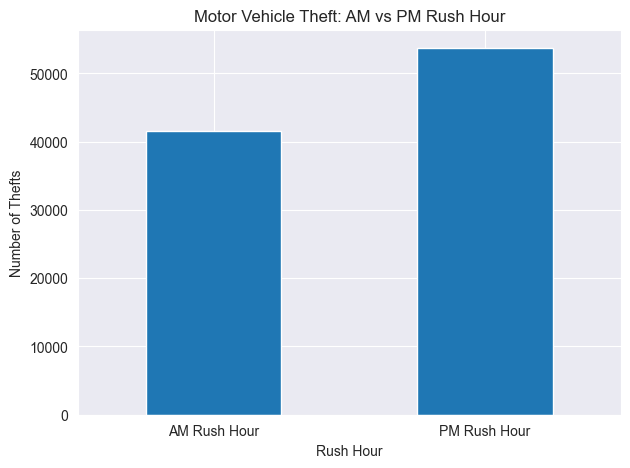

In [62]:
mvt_counts = pd.Series({
    "AM Rush Hour": am_mvt,
    "PM Rush Hour": pm_mvt
})

plt.figure(figsize=(7, 5))

mvt_counts.plot(kind="bar")

plt.title("Motor Vehicle Theft: AM vs PM Rush Hour")
plt.xlabel("Rush Hour")
plt.ylabel("Number of Thefts")

plt.xticks(rotation=0)
plt.show()

**Daily Crime Counts**
Resample the full dataset into a daily crime count series (`df_daily`).

In [63]:
df_daily = df.resample("D").size()

df_daily.head()

Date
2001-01-01    1825
2001-01-02    1143
2001-01-03    1151
2001-01-04    1166
2001-01-05    1267
Freq: D, dtype: int64

**Check Daily Frequency**
Inspect the inferred frequency of the daily series index.

In [64]:
df_daily.index.freq

<Day>

**Plot Daily Crime Counts (Full Period)**
Line chart of daily crime counts across the entire 2001–2022 dataset.

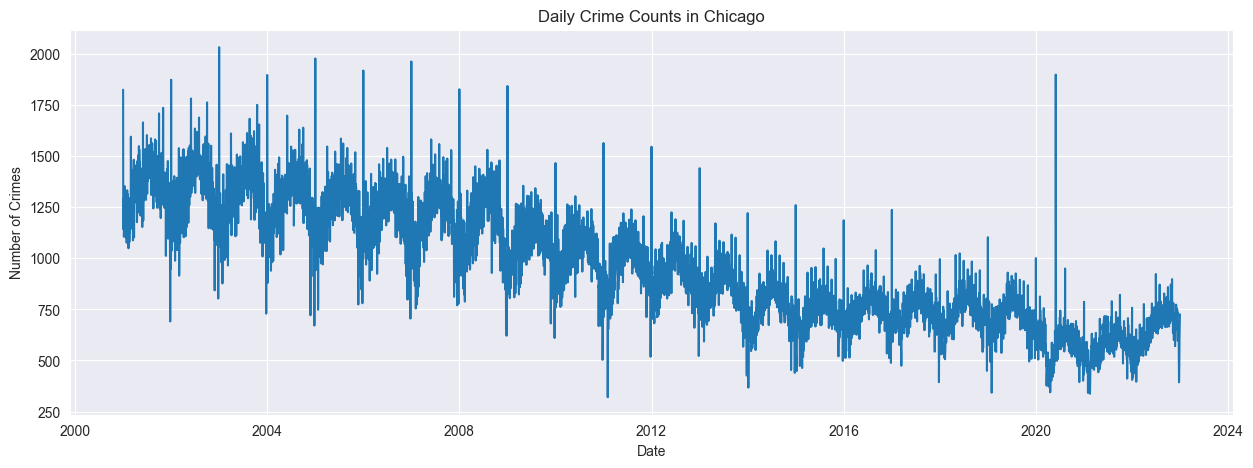

In [65]:
plt.figure(figsize=(15, 5))

plt.plot(df_daily)

plt.title("Daily Crime Counts in Chicago")
plt.xlabel("Date")
plt.ylabel("Number of Crimes")

plt.show()

**Plot Daily Crime Counts (2022 Only)**
Line chart zooming into daily crime counts for the year 2022.

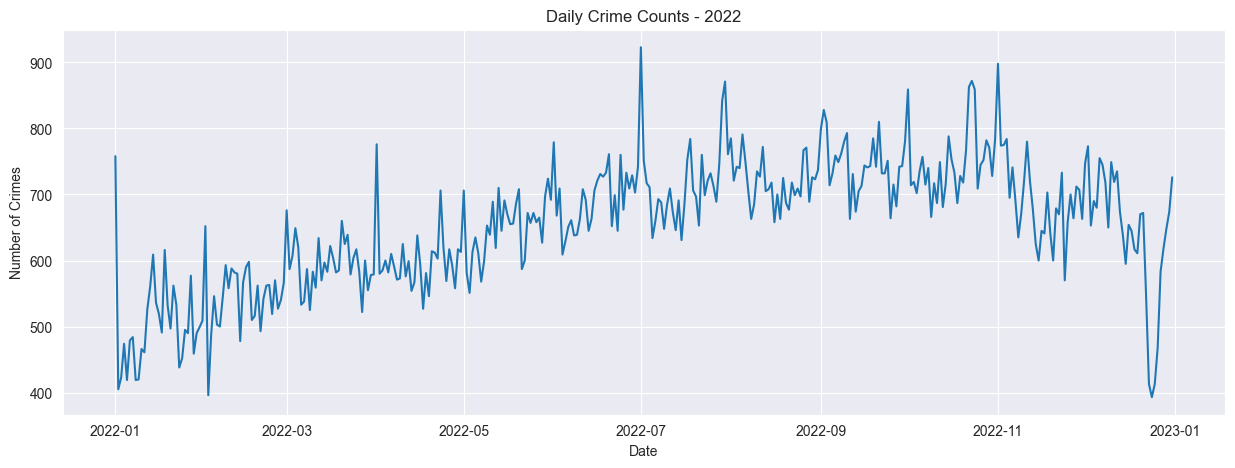

In [66]:
daily_2022 = df_daily.loc["2022"]

plt.figure(figsize=(15, 5))

plt.plot(daily_2022)

plt.title("Daily Crime Counts - 2022")
plt.xlabel("Date")
plt.ylabel("Number of Crimes")

plt.show()

**Import Seasonal Decomposition**
Import `seasonal_decompose` from `statsmodels`, used for the weekly and annual cycle analysis below.

In [68]:
from statsmodels.tsa.seasonal import seasonal_decompose

**Weekly Seasonal Decomposition**
Decompose the daily crime series into trend, seasonal, and residual components using a 7-day period to capture weekly cycles.

In [70]:
decomposition_weekly = seasonal_decompose(
    df_daily,
    model="additive",
    period=7
)

**Plot Weekly Decomposition**
Visualize the trend, weekly-seasonal, and residual components from the decomposition above.

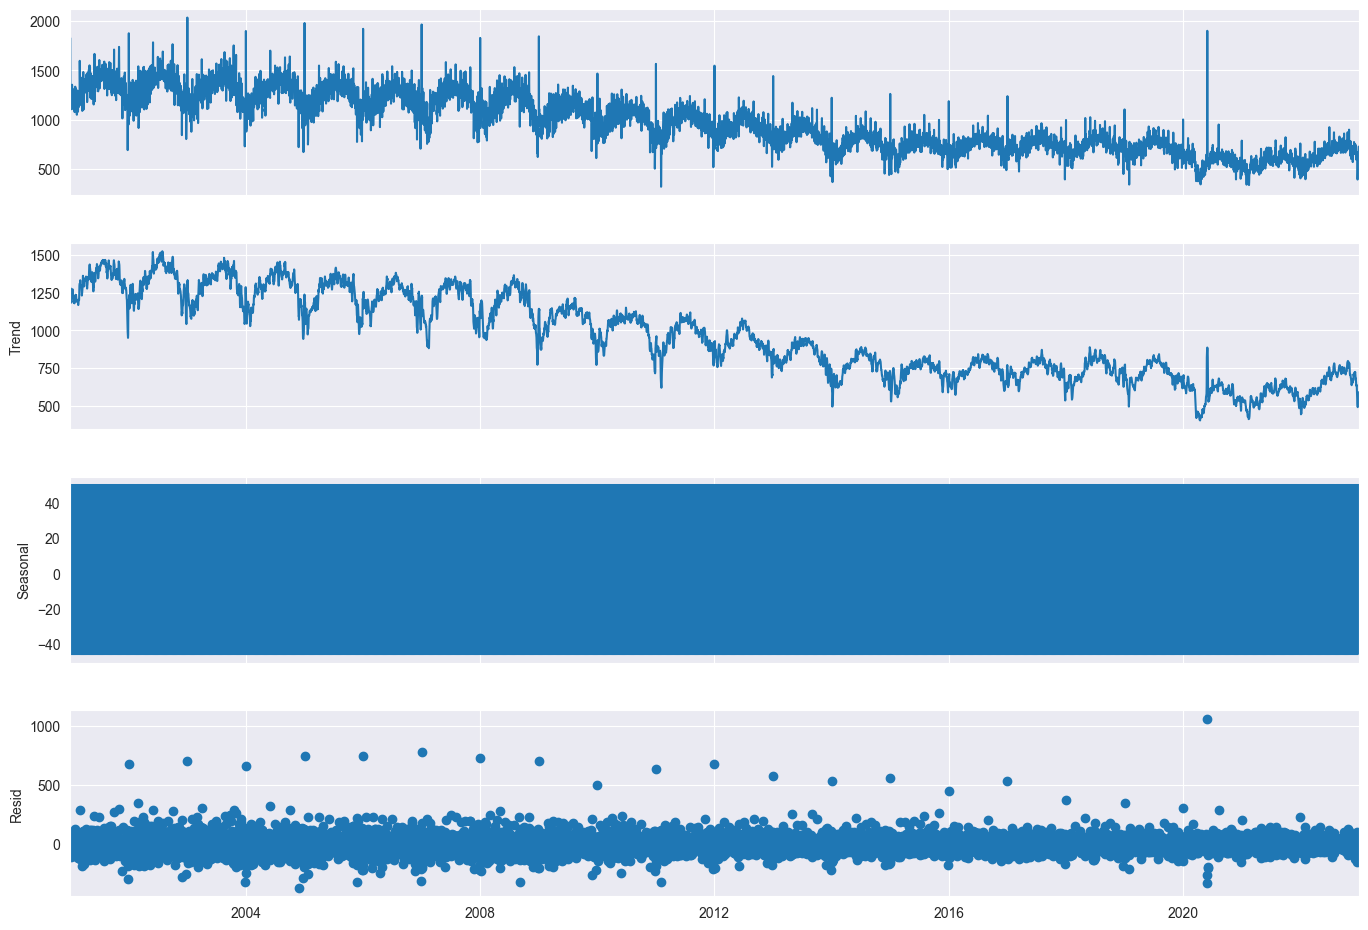

In [71]:
fig = decomposition_weekly.plot()
fig.set_size_inches(15, 10)
plt.show()

**Weekly Seasonal Magnitude**
Compute the minimum, maximum, and overall magnitude (max − min) of the weekly seasonal effect.

In [72]:
weekly_seasonal = decomposition_weekly.seasonal

weekly_min = weekly_seasonal.min()
weekly_max = weekly_seasonal.max()

weekly_magnitude = weekly_max - weekly_min

print("Weekly seasonal minimum:", weekly_min)
print("Weekly seasonal maximum:", weekly_max)
print("Weekly cycle magnitude:", weekly_magnitude)

Weekly seasonal minimum: -46.0409764603313
Weekly seasonal maximum: 50.196911196911195
Weekly cycle magnitude: 96.2378876572425


**Monthly Crime Counts**
Resample the full dataset into a monthly crime count series (`df_monthly`).

In [73]:
df_monthly = df.resample("MS").size()

df_monthly.head()

Date
2001-01-01    38119
2001-02-01    33787
2001-03-01    40566
2001-04-01    40091
2001-05-01    41839
Freq: MS, dtype: int64

**Plot Monthly Crime Counts**
Line chart of monthly crime counts across the full period.

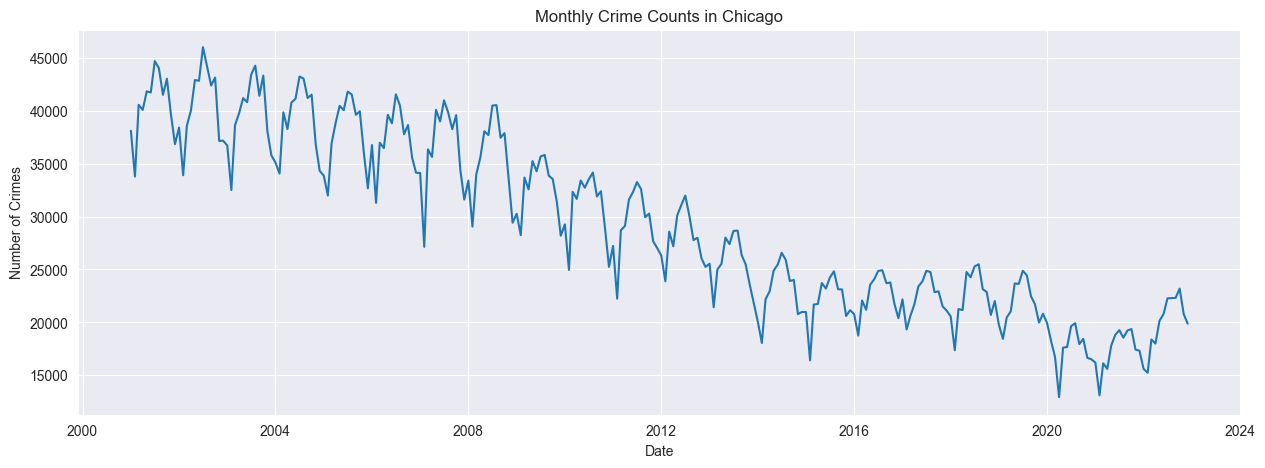

In [74]:
plt.figure(figsize=(15, 5))

plt.plot(df_monthly)

plt.title("Monthly Crime Counts in Chicago")
plt.xlabel("Date")
plt.ylabel("Number of Crimes")

plt.show()

**Annual Seasonal Decomposition**
Decompose the monthly crime series using a 12-month period to capture the yearly seasonal cycle.

In [75]:
decomposition_annual = seasonal_decompose(
    df_monthly,
    model="additive",
    period=12
)

**Plot Annual Decomposition**
Visualize the trend, annual-seasonal, and residual components from the decomposition above.

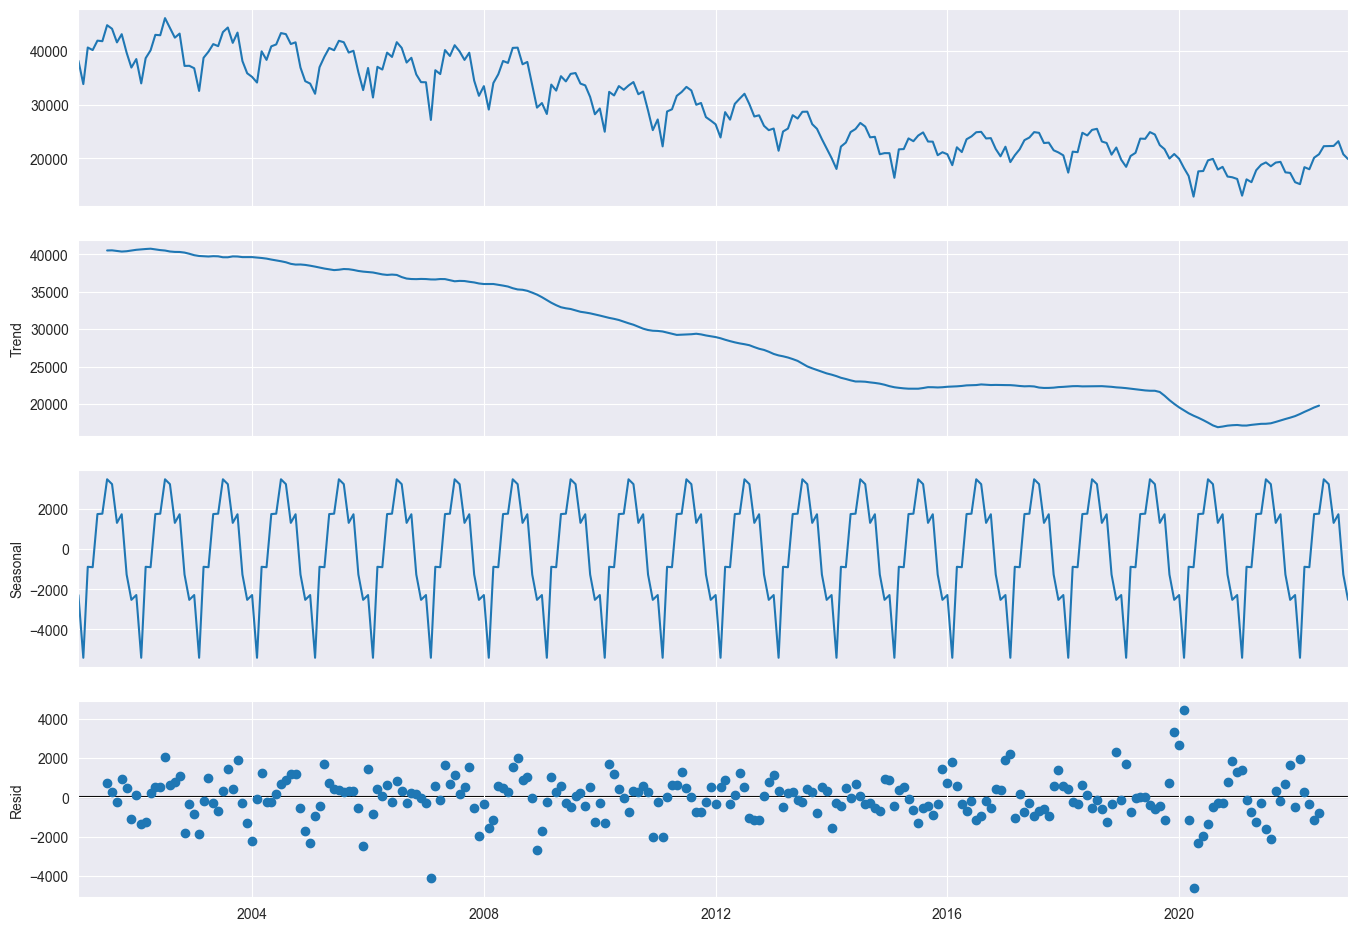

In [76]:
fig = decomposition_annual.plot()

fig.set_size_inches(15, 10)

plt.show()

**Annual Seasonal Magnitude**
Compute the minimum, maximum, and overall magnitude of the annual seasonal effect.

In [77]:
annual_seasonal = decomposition_annual.seasonal

annual_min = annual_seasonal.min()
annual_max = annual_seasonal.max()

annual_magnitude = annual_max - annual_min

print("Annual seasonal minimum:", annual_min)
print("Annual seasonal maximum:", annual_max)
print("Annual cycle magnitude:", annual_magnitude)

Annual seasonal minimum: -5416.088624338626
Annual seasonal maximum: 3481.6554232804237
Annual cycle magnitude: 8897.74404761905


**Average Seasonal Effect by Calendar Month**
Average the annual seasonal component for each calendar month (Jan–Dec) to see the typical shape of the yearly cycle.

In [78]:
seasonal_by_month = (
    annual_seasonal
    .groupby(annual_seasonal.index.month)
    .mean()
)

seasonal_by_month.index = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

seasonal_by_month

Jan   -2288.838624
Feb   -5416.088624
Mar    -880.852513
Apr    -901.207672
May    1747.381614
Jun    1766.518519
Jul    3481.655423
Aug    3238.863757
Sep    1308.881614
Oct    1737.972884
Nov   -1265.842593
Dec   -2528.443783
Name: seasonal, dtype: float64

**Highest Seasonal Month**
Identify which calendar month has the highest average seasonal effect (the peak of the crime cycle).

In [79]:
highest_month = seasonal_by_month.idxmax()
highest_value = seasonal_by_month.max()

print("Highest seasonal month:", highest_month)
print("Seasonal value:", highest_value)

Highest seasonal month: Jul
Seasonal value: 3481.6554232804237


**Lowest Seasonal Month**
Identify which calendar month has the lowest average seasonal effect ( the trough of the crime cycle).

In [80]:
lowest_month = seasonal_by_month.idxmin()
lowest_value = seasonal_by_month.min()

print("Lowest seasonal month:", lowest_month)
print("Seasonal value:", lowest_value)

Lowest seasonal month: Feb
Seasonal value: -5416.088624338626


**Plot Annual Seasonal Pattern**
Line chart showing the average seasonal effect for each calendar month.

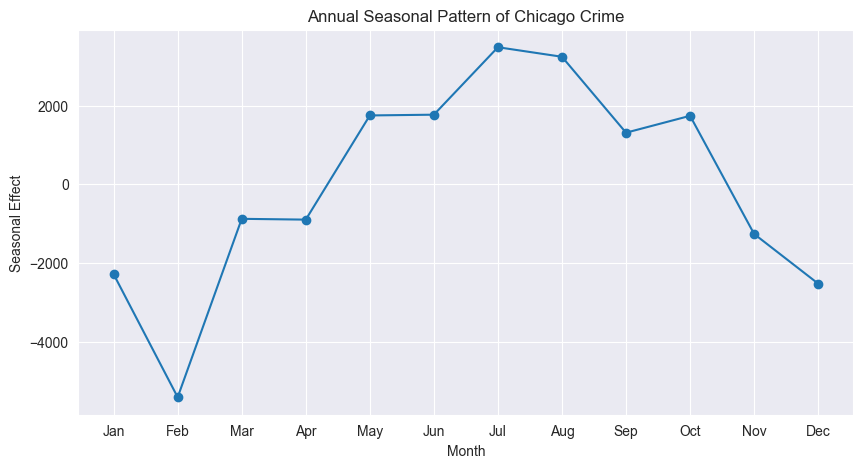

In [81]:
plt.figure(figsize=(10, 5))

plt.plot(
    seasonal_by_month.index,
    seasonal_by_month.values,
    marker="o"
)

plt.title("Annual Seasonal Pattern of Chicago Crime")
plt.xlabel("Month")
plt.ylabel("Seasonal Effect")

plt.grid(True)

plt.show()

**Monthly Theft Series**:

Filter the data to `THEFT` crimes and resample into a monthly count series (`theft_ts`).

In [83]:
theft_ts = df[df["Primary Type"] == "THEFT"].resample("MS").size()

**Monthly Narcotics Series**:

Filter the data to `NARCOTICS` crimes and resample into a monthly count series (`narcotics_ts`).

In [84]:
narcotics_ts = df[df["Primary Type"] == "NARCOTICS"].resample("MS").size()

**Preview Both Series**
Show the first rows of the monthly Theft and Narcotics series.

In [85]:
print("Theft:")
print(theft_ts.head())

print("\nNarcotics:")
print(narcotics_ts.head())

Theft:
Date
2001-01-01    7867
2001-02-01    6669
2001-03-01    7766
2001-04-01    7702
2001-05-01    8420
Freq: MS, dtype: int64

Narcotics:
Date
2001-01-01    4714
2001-02-01    4369
2001-03-01    4862
2001-04-01    4044
2001-05-01    4038
Freq: MS, dtype: int64


**Check Data Quality**
Check both series for missing values and zero-count months.

In [87]:
print("Theft nulls:", theft_ts.isna().sum())
print("Theft zeros:", (theft_ts == 0).sum())

print("Narcotics nulls:", narcotics_ts.isna().sum())
print("Narcotics zeros:", (narcotics_ts == 0).sum())

Theft nulls: 0
Theft zeros: 0
Narcotics nulls: 0
Narcotics zeros: 0


**Plot Monthly Theft Crimes**
Line chart of the monthly Theft series.

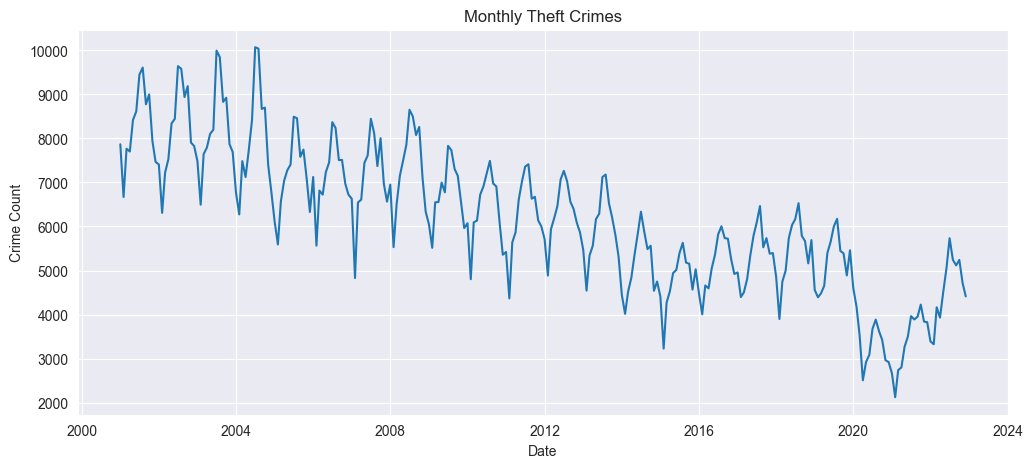

In [88]:
plt.figure(figsize=(12, 5))

plt.plot(theft_ts)

plt.title("Monthly Theft Crimes")
plt.xlabel("Date")
plt.ylabel("Crime Count")

plt.show()

**Plot Monthly Narcotics Crimes**
Line chart of the monthly Narcotics series.

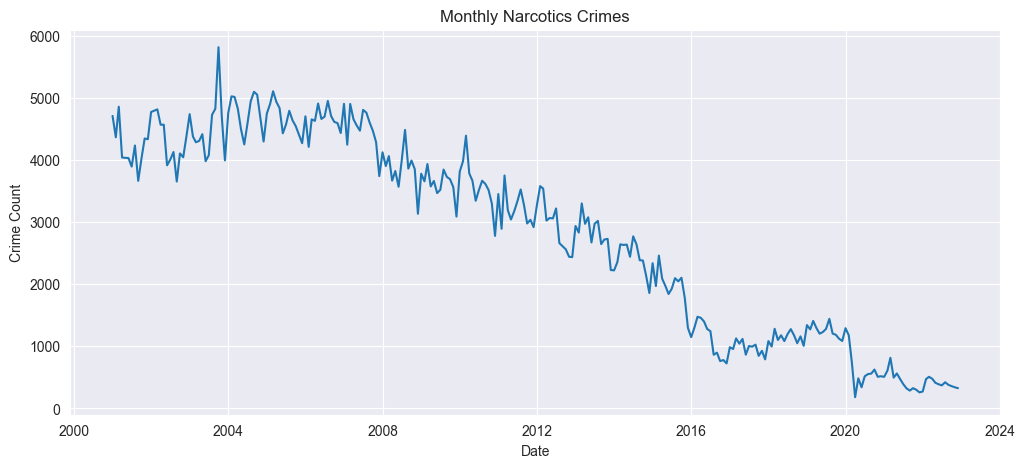

In [89]:
plt.figure(figsize=(12, 5))

plt.plot(narcotics_ts)

plt.title("Monthly Narcotics Crimes")
plt.xlabel("Date")
plt.ylabel("Crime Count")

plt.show()

**Decompose Theft Series**
Seasonal decomposition (period=12) of the monthly Theft series, plotted to inspect trend/seasonality/residuals.

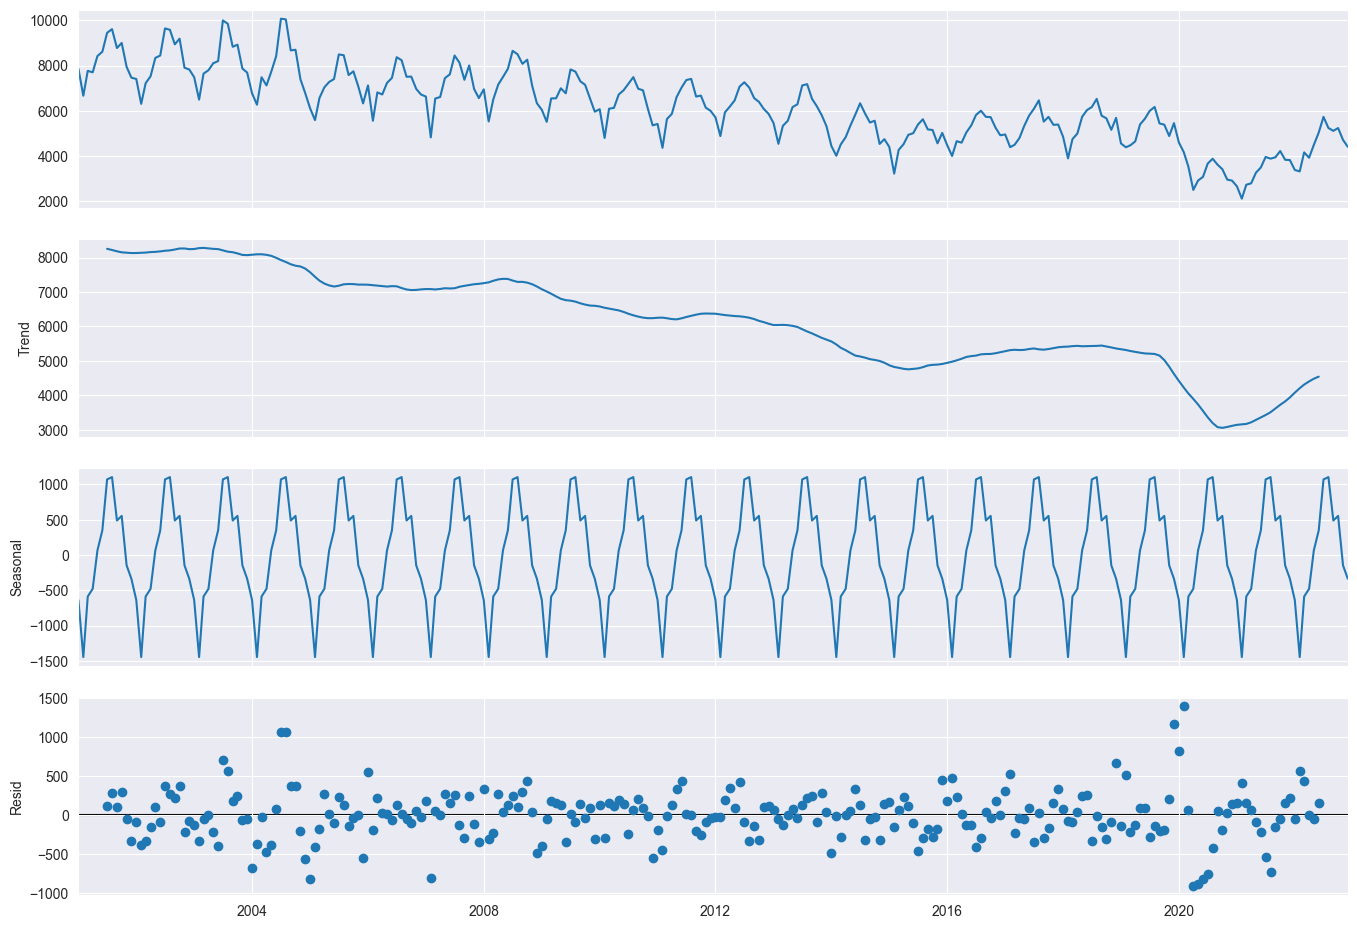

In [90]:
theft_decomp = seasonal_decompose(
    theft_ts,
    model="additive",
    period=12
)

fig = theft_decomp.plot()
fig.set_size_inches(15, 10)

plt.show()

**Decompose Narcotics Series**
Seasonal decomposition (period=12) of the monthly Narcotics series, plotted to inspect trend/seasonality/residuals.

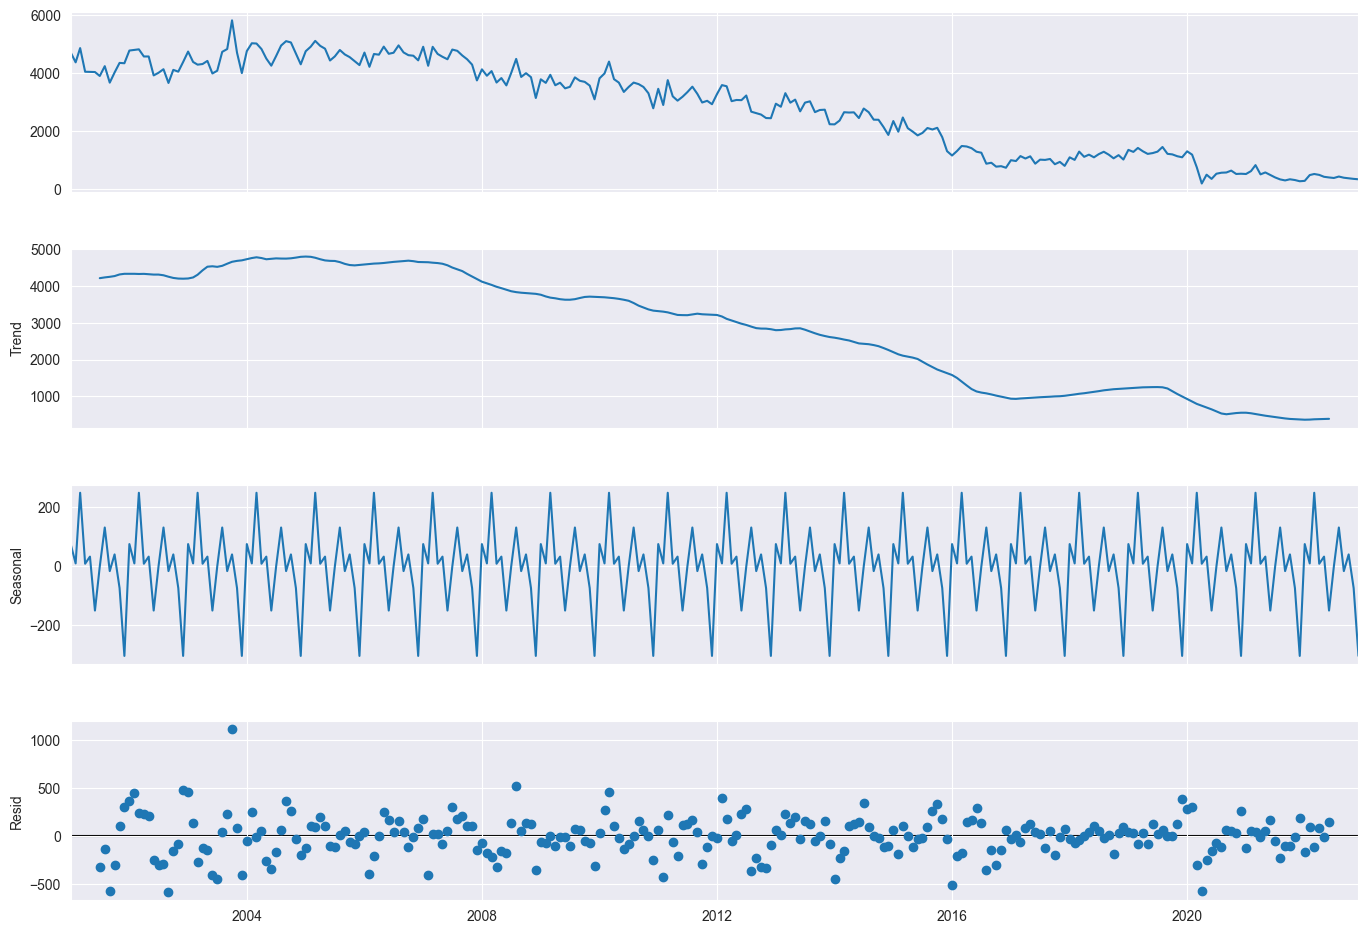

In [91]:
narcotics_decomp = seasonal_decompose(
    narcotics_ts,
    model="additive",
    period=12
)

fig = narcotics_decomp.plot()
fig.set_size_inches(15, 10)

plt.show()

**Stationarity Test: Theft**
Run the (ADF) test on the raw Theft series to check for stationarity.

In [92]:
theft_adf = adfuller(theft_ts.dropna())

print("ADF Statistic:", theft_adf[0])
print("p-value:", theft_adf[1])

ADF Statistic: -1.3939354159921726
p-value: 0.5851800781286366


**Stationarity Test: Narcotics**
Run the ADF test on the raw Narcotics series.

In [93]:
narcotics_adf = adfuller(narcotics_ts.dropna())

print("ADF Statistic:", narcotics_adf[0])
print("p-value:", narcotics_adf[1])

ADF Statistic: 0.26547211924266184
p-value: 0.9757037145039906


**Seasonal Differencing**
Apply 12-month seasonal differencing to both the Theft and Narcotics series to remove the yearly seasonal pattern.

In [95]:
# Seasonal differencing: 12 months

theft_seasonal_diff = theft_ts.diff(12).dropna()

narcotics_seasonal_diff = narcotics_ts.diff(12).dropna()

**Re-test Stationarity After Seasonal Differencing**
Run the ADF test again on both seasonally differenced series.

In [96]:
print(
    "Theft seasonal differencing p-value:",
    adfuller(theft_seasonal_diff)[1]
)

print(
    "Narcotics seasonal differencing p-value:",
    adfuller(narcotics_seasonal_diff)[1]
)

Theft seasonal differencing p-value: 0.0017883046943635039
Narcotics seasonal differencing p-value: 0.07611895991335649


**Additional Differencing for Narcotics**
Apply both a regular (first) difference and a 12-month seasonal difference to the Narcotics series.

In [97]:
narcotics_diff = narcotics_ts.diff().diff(12).dropna()

**Re-test Stationarity for Narcotics**
Run the ADF test on the doubly differenced Narcotics series.

In [98]:
narcotics_diff_adf = adfuller(narcotics_diff)

print("Narcotics differenced ADF Statistic:",
      narcotics_diff_adf[0])

print("Narcotics differenced p-value:",
      narcotics_diff_adf[1])

Narcotics differenced ADF Statistic: -6.420307075451568
Narcotics differenced p-value: 1.798400805178999e-08


**Prepare Stationary Theft Series**
Apply 12-month seasonal differencing to Theft to obtain a stationary series for ACF/PACF analysis.

In [100]:
theft_stationary = theft_ts.diff(12).dropna()

**Plot ACF/PACF: Theft**
Visualize the autocorrelation and partial autocorrelation of the stationary Theft series to help choose ARIMA parameters.

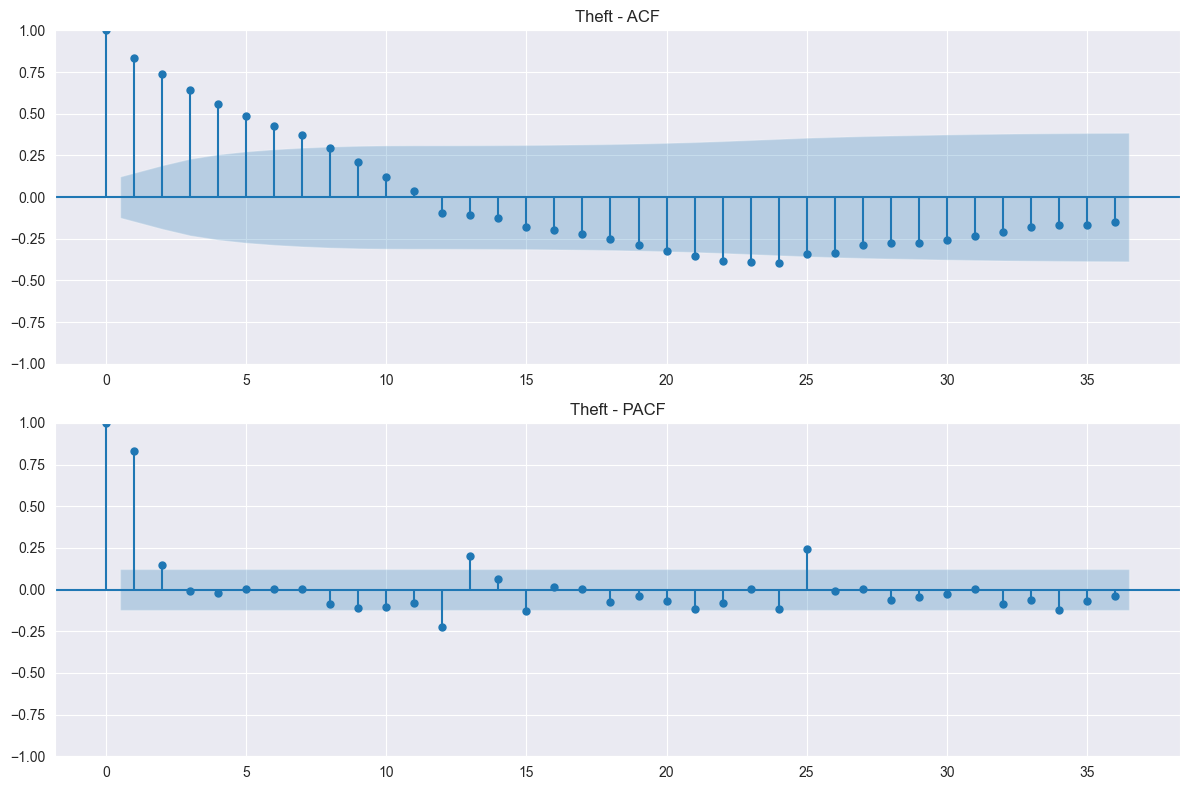

In [101]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(theft_stationary, ax=axes[0], lags=36)
plot_pacf(theft_stationary, ax=axes[1], lags=36)

axes[0].set_title("Theft - ACF")
axes[1].set_title("Theft - PACF")

plt.tight_layout()
plt.show()

**Prepare Stationary Narcotics Series**
Apply regular plus 12-month seasonal differencing to Narcotics to obtain a stationary series.

In [102]:
narcotics_stationary = narcotics_ts.diff().diff(12).dropna()

**Plot ACF/PACF: Narcotics**
Visualize the autocorrelation and partial autocorrelation of the stationary Narcotics series to help choose ARIMA parameters.

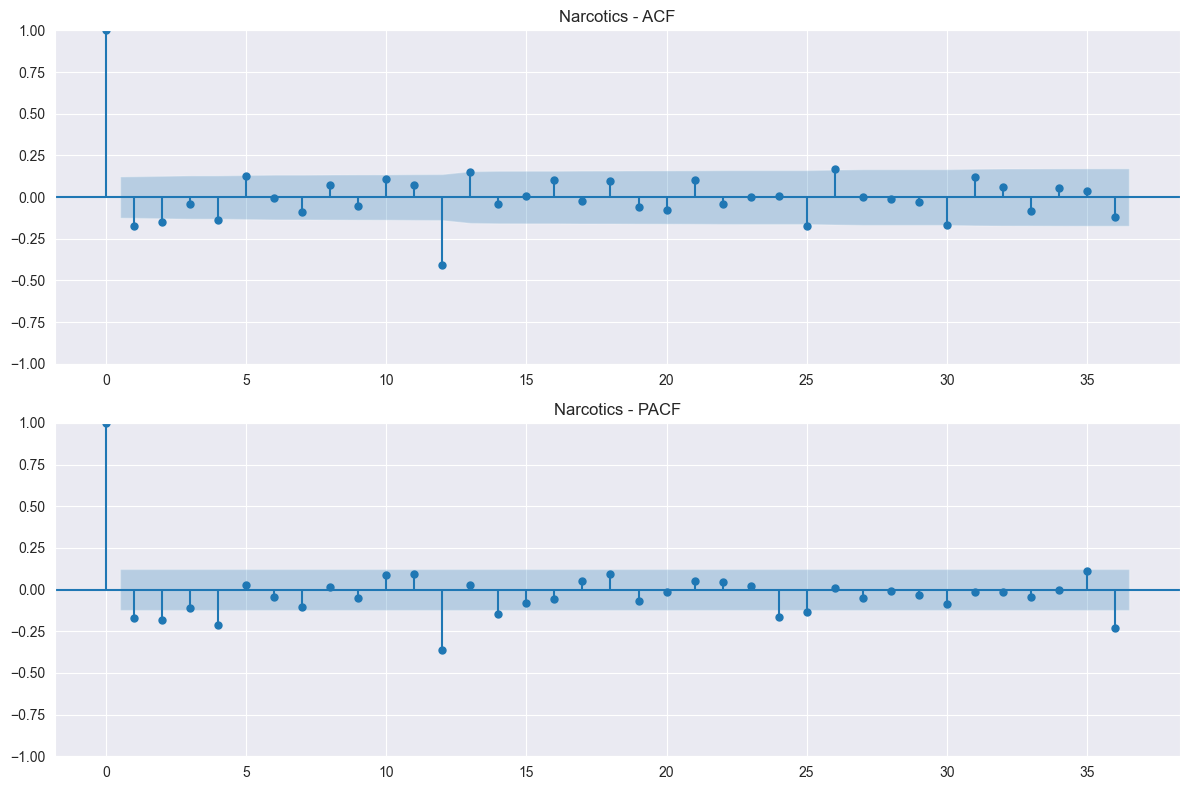

In [103]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(narcotics_stationary, ax=axes[0], lags=36)
plot_pacf(narcotics_stationary, ax=axes[1], lags=36)

axes[0].set_title("Narcotics - ACF")
axes[1].set_title("Narcotics - PACF")

plt.tight_layout()
plt.show()

**Train/Test Split: Theft**
Split the Theft series into a training set and a 6-month test set held out for evaluation.

In [104]:
theft_train = theft_ts.iloc[:-6]
theft_test = theft_ts.iloc[-6:]

print("Theft train:", theft_train.index.min(), "to", theft_train.index.max())
print("Theft test:", theft_test.index.min(), "to", theft_test.index.max())

Theft train: 2001-01-01 00:00:00 to 2022-06-01 00:00:00
Theft test: 2022-07-01 00:00:00 to 2022-12-01 00:00:00


**Train/Test Split: Narcotics**
Split the Narcotics series into a training set and a 6-month test set.

In [105]:
narcotics_train = narcotics_ts.iloc[:-6]
narcotics_test = narcotics_ts.iloc[-6:]

print("Narcotics train:", narcotics_train.index.min(), "to", narcotics_train.index.max())
print("Narcotics test:", narcotics_test.index.min(), "to", narcotics_test.index.max())

Narcotics train: 2001-01-01 00:00:00 to 2022-06-01 00:00:00
Narcotics test: 2022-07-01 00:00:00 to 2022-12-01 00:00:00


**Check Test Set Sizes**
Confirm the number of months held out in each test set.

In [106]:
print("Theft test months:", len(theft_test))
print("Narcotics test months:", len(narcotics_test))

Theft test months: 6
Narcotics test months: 6


**Fit SARIMA Model: Theft**
Fit a manually specified SARIMA model (order=(1,0,0), seasonal_order=(0,1,0,12)) on the Theft training data and print the model summary.

In [107]:
theft_model = ARIMA(
    theft_train,
    order=(1, 0, 0),
    seasonal_order=(0, 1, 0, 12)
)

theft_model_fit = theft_model.fit()

print(theft_model_fit.summary())

                                    SARIMAX Results                                     
Dep. Variable:                                y   No. Observations:                  258
Model:             ARIMA(1, 0, 0)x(0, 1, 0, 12)   Log Likelihood               -1835.553
Date:                          Sat, 29 Aug 2026   AIC                           3675.105
Time:                                  20:56:11   BIC                           3682.116
Sample:                              01-01-2001   HQIC                          3677.928
                                   - 06-01-2022                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7022      0.009     77.376      0.000       0.684       0.720
sigma2      1.547e+05   1.19e+04     13.020      0.

**Fit SARIMA Model: Narcotics**
Fit a manually specified SARIMA model (order=(1,1,0), seasonal_order=(0,1,0,12)) on the Narcotics training data and print the model summary.

In [108]:
narcotics_model = ARIMA(
    narcotics_train,
    order=(1, 1, 0),
    seasonal_order=(0, 1, 0, 12)
)

narcotics_model_fit = narcotics_model.fit()

print(narcotics_model_fit.summary())

                                    SARIMAX Results                                     
Dep. Variable:                                y   No. Observations:                  258
Model:             ARIMA(1, 1, 0)x(0, 1, 0, 12)   Log Likelihood               -1741.829
Date:                          Sat, 29 Aug 2026   AIC                           3487.659
Time:                                  20:56:22   BIC                           3494.661
Sample:                              01-01-2001   HQIC                          3490.478
                                   - 06-01-2022                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1763      0.043     -4.066      0.000      -0.261      -0.091
sigma2       8.76e+04   5953.615     14.714      0.

**Forecast Theft (Manual SARIMA)**
Generate a 6-month forecast from the fitted Theft SARIMA model.

In [109]:
theft_forecast = theft_model_fit.forecast(steps=6)

theft_forecast

2022-07-01    5047.567368
2022-08-01    4649.932107
2022-09-01    4486.362411
2022-10-01    4602.254486
2022-11-01    4103.521397
2022-12-01    4012.057153
Freq: MS, Name: predicted_mean, dtype: float64

**Compare Theft Forecast vs Actual**
Build a table pairing the actual test values against the SARIMA forecast for Theft.

In [110]:
theft_results = pd.DataFrame({
    "Actual": theft_test.values,
    "Forecast": theft_forecast.values
}, index=theft_test.index)

theft_results

,Actual,Forecast
Date,,
2022-07-01,5734,5047.567368
2022-08-01,5244,4649.932107
2022-09-01,5117,4486.362411
2022-10-01,5242,4602.254486
2022-11-01,4717,4103.521397
2022-12-01,4413,4012.057153


**Plot Theft Forecast vs Actual**
Plot the training data, actual test values, and SARIMA forecast for Theft together.

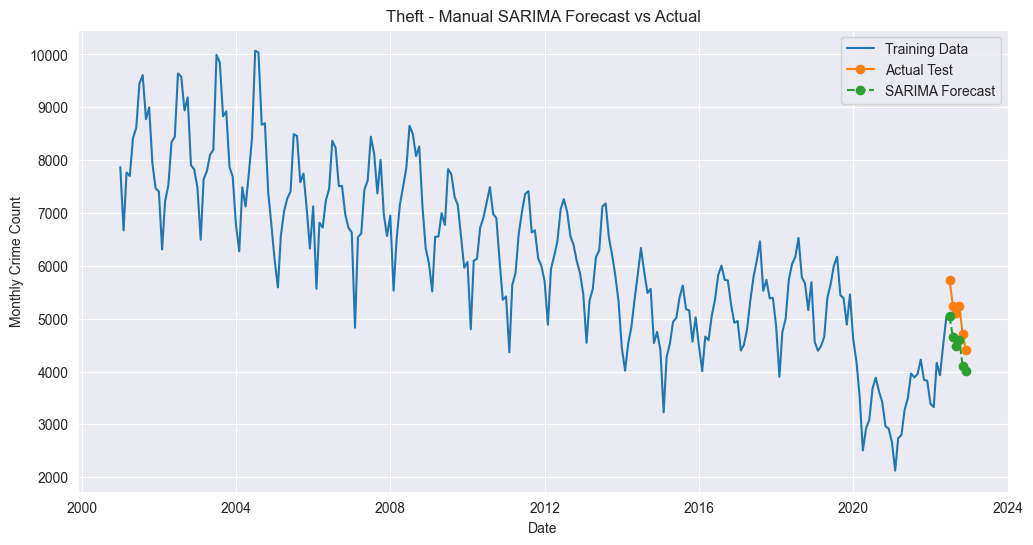

In [111]:
plt.figure(figsize=(12, 6))

plt.plot(
    theft_train.index,
    theft_train,
    label="Training Data"
)

plt.plot(
    theft_test.index,
    theft_test,
    marker="o",
    label="Actual Test"
)

plt.plot(
    theft_forecast.index,
    theft_forecast,
    marker="o",
    linestyle="--",
    label="SARIMA Forecast"
)

plt.title("Theft - Manual SARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Monthly Crime Count")

plt.legend()
plt.grid(True)

plt.show()

**Evaluate Theft Forecast**
Compute MAE, RMSE, and MAPE to quantify the accuracy of the manual SARIMA Theft forecast.

In [112]:
theft_mae = mean_absolute_error(
    theft_test,
    theft_forecast
)

theft_rmse = np.sqrt(
    mean_squared_error(
        theft_test,
        theft_forecast
    )
)

theft_mape = np.mean(
    np.abs(
        (theft_test - theft_forecast) / theft_test
    )
) * 100

print("Theft MAE:", theft_mae)
print("Theft RMSE:", theft_rmse)
print("Theft MAPE:", theft_mape, "%")

Theft MAE: 594.2175131288192
Theft RMSE: 601.1372104585733
Theft MAPE: 11.653261958754356 %


**Forecast Narcotics (Manual SARIMA)**
Generate a 6-month forecast from the fitted Narcotics SARIMA model.

In [113]:
narcotics_forecast = narcotics_model_fit.forecast(steps=6)

narcotics_forecast

2022-07-01    293.190721
2022-08-01    227.272200
2022-09-01    191.905323
2022-10-01    230.969988
2022-11-01    204.958590
2022-12-01    162.960599
Freq: MS, Name: predicted_mean, dtype: float64

**Compare Narcotics Forecast vs Actual**
Build a table pairing the actual test values against the SARIMA forecast for Narcotics.

In [114]:
narcotics_results = pd.DataFrame({
    "Actual": narcotics_test.values,
    "Forecast": narcotics_forecast.values
}, index=narcotics_test.index)

narcotics_results

,Actual,Forecast
Date,,
2022-07-01,370,293.190721
2022-08-01,420,227.272200
2022-09-01,379,191.905323
2022-10-01,358,230.969988
2022-11-01,339,204.958590
2022-12-01,325,162.960599


**Plot Narcotics Forecast vs Actual**
Plot the training data, actual test values, and SARIMA forecast for Narcotics together.

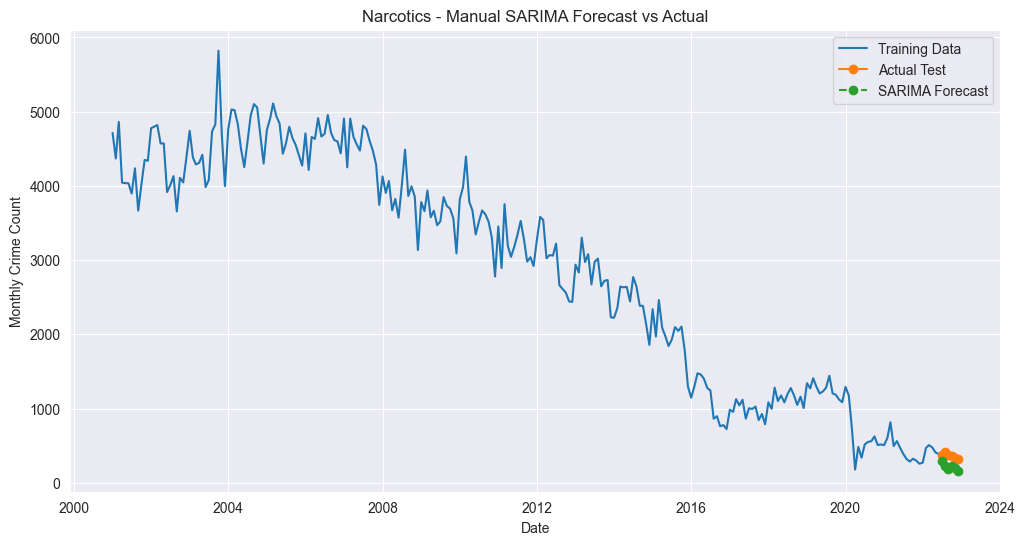

In [115]:
plt.figure(figsize=(12, 6))

plt.plot(
    narcotics_train.index,
    narcotics_train,
    label="Training Data"
)

plt.plot(
    narcotics_test.index,
    narcotics_test,
    marker="o",
    label="Actual Test"
)

plt.plot(
    narcotics_forecast.index,
    narcotics_forecast,
    marker="o",
    linestyle="--",
    label="SARIMA Forecast"
)

plt.title("Narcotics - Manual SARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Monthly Crime Count")

plt.legend()
plt.grid(True)

plt.show()

**Evaluate Narcotics Forecast**
Compute MAE, RMSE, and MAPE to quantify the accuracy of the manual SARIMA Narcotics forecast.

In [116]:
narcotics_mae = mean_absolute_error(
    narcotics_test,
    narcotics_forecast
)

narcotics_rmse = np.sqrt(
    mean_squared_error(
        narcotics_test,
        narcotics_forecast
    )
)

narcotics_mape = np.mean(
    np.abs(
        (narcotics_test - narcotics_forecast) / narcotics_test
    )
) * 100

print("Narcotics MAE:", narcotics_mae)
print("Narcotics RMSE:", narcotics_rmse)
print("Narcotics MAPE:", narcotics_mape, "%")

Narcotics MAE: 146.62376324647553
Narcotics RMSE: 151.8818507993572
Narcotics MAPE: 40.14899100393828 %


**Auto-ARIMA Search: Theft**
Use `pmdarima.auto_arima` to automatically search for the best-fitting seasonal ARIMA order for the Theft training data.

In [117]:
auto_theft = pm.auto_arima(
    theft_train,
    seasonal=True,
    m=12,
    stepwise=True,
    trace=True,
    suppress_warnings=True,
    error_action="ignore"
)

print(auto_theft.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.60 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=4050.524, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=3791.710, Time=0.17 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=3914.631, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=4048.603, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=4050.805, Time=0.02 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=3774.214, Time=0.50 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=3744.069, Time=1.18 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=3743.960, Time=0.41 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=3913.736, Time=0.13 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=3742.899, Time=0.92 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=3870.719, Time=0.33 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=inf, Time=0.63 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=3754.859, Time=0.68 sec
 ARIMA(2,1,0)(1,0,2)[12] inte

**Auto-ARIMA Search: Narcotics**
Use `pmdarima.auto_arima` to automatically search for the best-fitting seasonal ARIMA order for the Narcotics training data.

In [118]:
auto_narcotics = pm.auto_arima(
    narcotics_train,
    seasonal=True,
    m=12,
    stepwise=True,
    trace=True,
    suppress_warnings=True,
    error_action="ignore"
)

print(auto_narcotics.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.89 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=3669.016, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=3583.957, Time=0.36 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=3595.909, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=3667.813, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=3643.189, Time=0.01 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=3577.354, Time=0.66 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=3559.635, Time=0.86 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=3559.679, Time=0.31 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=inf, Time=0.88 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=3559.353, Time=0.67 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=3589.825, Time=0.26 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=3602.922, Time=0.10 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=3566.653, Time=0.62 sec
 ARIMA(2,1,0)(1,0,2)[12] inte

**Evaluate Auto-ARIMA: Theft**
Forecast the test period with the auto-selected Theft model and compute MAE, RMSE, and MAPE.

In [119]:
auto_theft_forecast = auto_theft.predict(n_periods=6)

auto_theft_mae = mean_absolute_error(
    theft_test,
    auto_theft_forecast
)

auto_theft_rmse = np.sqrt(
    mean_squared_error(
        theft_test,
        auto_theft_forecast
    )
)

auto_theft_mape = np.mean(
    np.abs(
        (theft_test.values - auto_theft_forecast)
        / theft_test.values
    )
) * 100

print("Auto Theft MAE:", auto_theft_mae)
print("Auto Theft RMSE:", auto_theft_rmse)
print("Auto Theft MAPE:", auto_theft_mape)

Auto Theft MAE: 211.16118153654315
Auto Theft RMSE: 269.8268592640573
Auto Theft MAPE: 4.273339908459043


**Evaluate Auto-ARIMA: Narcotics**
Forecast the test period with the auto-selected Narcotics model and compute MAE, RMSE, and MAPE.

In [120]:
auto_narcotics_forecast = auto_narcotics.predict(n_periods=6)

auto_narcotics_mae = mean_absolute_error(
    narcotics_test,
    auto_narcotics_forecast
)

auto_narcotics_rmse = np.sqrt(
    mean_squared_error(
        narcotics_test,
        auto_narcotics_forecast
    )
)

auto_narcotics_mape = np.mean(
    np.abs(
        (narcotics_test.values - auto_narcotics_forecast)
        / narcotics_test.values
    )
) * 100

print("Auto Narcotics MAE:", auto_narcotics_mae)
print("Auto Narcotics RMSE:", auto_narcotics_rmse)
print("Auto Narcotics MAPE:", auto_narcotics_mape)

Auto Narcotics MAE: 34.5647900945535
Auto Narcotics RMSE: 42.772217266415126
Auto Narcotics MAPE: 9.876428404960324


**Plot Auto-SARIMA Forecast: Theft**
Plot the training data, actual test values, and auto-ARIMA forecast for Theft.

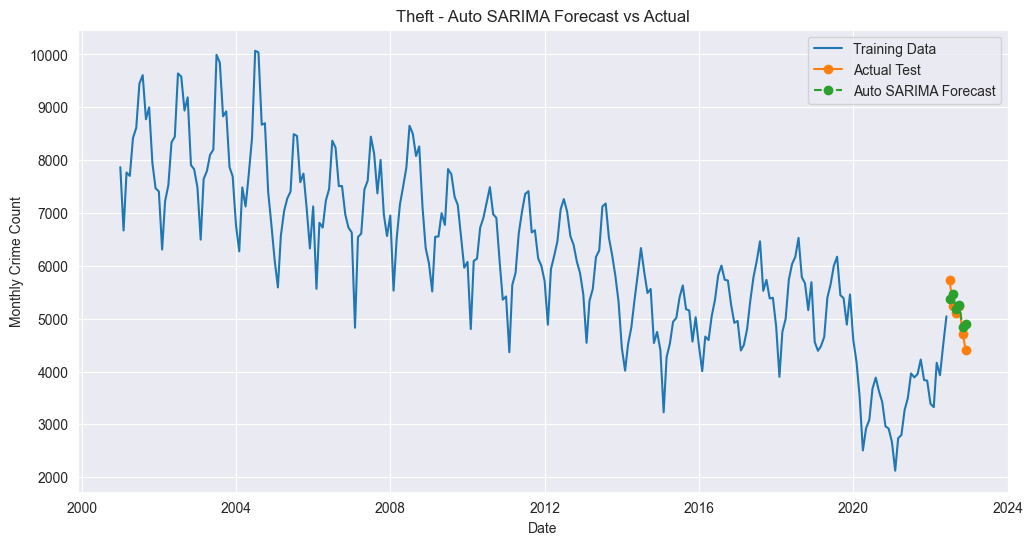

In [121]:
plt.figure(figsize=(12, 6))

plt.plot(
    theft_train.index,
    theft_train,
    label="Training Data"
)

plt.plot(
    theft_test.index,
    theft_test,
    marker="o",
    label="Actual Test"
)

plt.plot(
    theft_test.index,
    auto_theft_forecast,
    marker="o",
    linestyle="--",
    label="Auto SARIMA Forecast"
)

plt.title("Theft - Auto SARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Monthly Crime Count")

plt.legend()
plt.grid(True)

plt.show()

**Plot Auto-SARIMA Forecast: Narcotics**
Plot the training data, actual test values, and auto-ARIMA forecast for Narcotics.

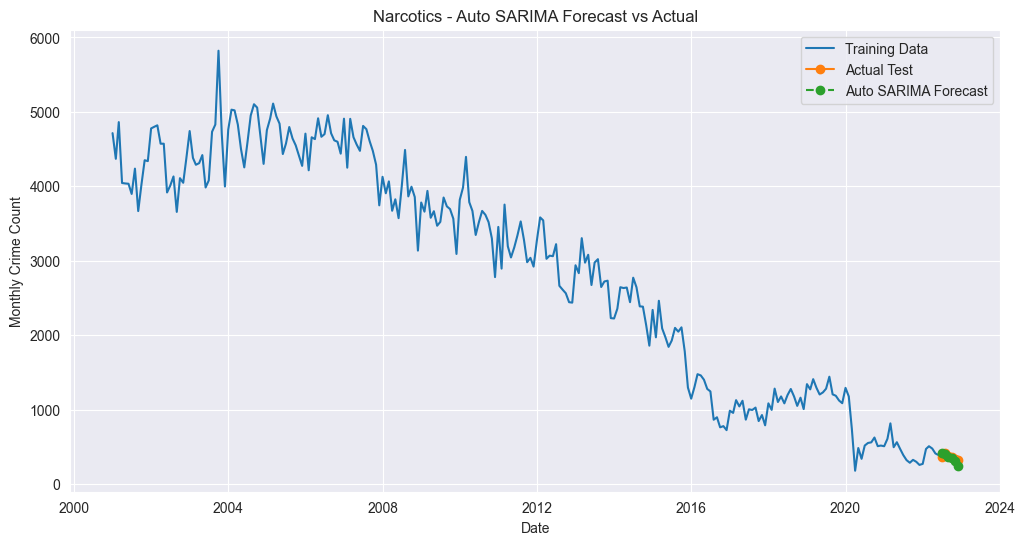

In [122]:
plt.figure(figsize=(12, 6))

plt.plot(
    narcotics_train.index,
    narcotics_train,
    label="Training Data"
)

plt.plot(
    narcotics_test.index,
    narcotics_test,
    marker="o",
    label="Actual Test"
)

plt.plot(
    narcotics_test.index,
    auto_narcotics_forecast,
    marker="o",
    linestyle="--",
    label="Auto SARIMA Forecast"
)

plt.title("Narcotics - Auto SARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Monthly Crime Count")

plt.legend()
plt.grid(True)

plt.show()

**Fit Final Theft Model on Full Data**
Refit a model using the best order found by auto-ARIMA, this time on the entire Theft series (not just the training portion), in preparation for a true future forecast.

In [123]:
final_theft_model = pm.ARIMA(
    order=auto_theft.order,
    seasonal_order=auto_theft.seasonal_order
)

final_theft_model.fit(theft_ts)

C:\Users\RaNia PC\PycharmProjects\JupyterProject\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,order,"(1, ...)"
,seasonal_order,"(1, ...)"
,start_params,None
,method,'lbfgs'
,maxiter,50
,suppress_warnings,False
,out_of_sample_size,0
,scoring,'mse'
,scoring_args,None
,trend,None
,with_intercept,True


**Forecast Future Theft (6 Months Ahead)**
Generate a 6-month-ahead forecast for Theft using the final model fitted on all available data.

In [124]:
future_theft = final_theft_model.predict(n_periods=6)

future_theft

2023-01-01    4024.795556
2023-02-01    3672.501394
2023-03-01    4180.226413
2023-04-01    4031.713546
2023-05-01    4539.033022
2023-06-01    4891.204266
Freq: MS, dtype: float64

**Fit Final Narcotics Model on Full Data**
Refit a model using the best order found by auto-ARIMA, this time on the entire Narcotics series, in preparation for a true future forecast.

In [125]:
final_narcotics_model = pm.ARIMA(
    order=auto_narcotics.order,
    seasonal_order=auto_narcotics.seasonal_order
)

final_narcotics_model.fit(narcotics_ts)

C:\Users\RaNia PC\PycharmProjects\JupyterProject\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,order,"(4, ...)"
,seasonal_order,"(1, ...)"
,start_params,None
,method,'lbfgs'
,maxiter,50
,suppress_warnings,False
,out_of_sample_size,0
,scoring,'mse'
,scoring_args,None
,trend,None
,with_intercept,True


**Forecast Future Narcotics (6 Months Ahead)**
Generate a 6-month-ahead forecast for Narcotics using the final model fitted on all available data.

In [126]:
future_narcotics = final_narcotics_model.predict(
    n_periods=6
)

future_narcotics

2023-01-01    406.650711
2023-02-01    425.318807
2023-03-01    472.658263
2023-04-01    297.917127
2023-05-01    331.150655
2023-06-01    264.445820
Freq: MS, dtype: float64

**Build Future Date Range**
Create the sequence of the next 6 month-start dates following the end of the historical data.

In [127]:
future_dates = pd.date_range(
    start=theft_ts.index[-1] + pd.offsets.MonthBegin(1),
    periods=6,
    freq="MS"
)

**Attach Dates to Forecasts**
Assign the future date range as the index of both the Theft and Narcotics forecast series.

In [128]:
future_theft = pd.Series(
    future_theft,
    index=future_dates
)

future_narcotics = pd.Series(
    future_narcotics,
    index=future_dates
)

**Print Future Forecasts**
Display the final 6-month-ahead forecasts for both Theft and Narcotics.

In [129]:
print("Future Theft Forecast:")
print(future_theft)

print("\nFuture Narcotics Forecast:")
print(future_narcotics)

Future Theft Forecast:
2023-01-01    4024.795556
2023-02-01    3672.501394
2023-03-01    4180.226413
2023-04-01    4031.713546
2023-05-01    4539.033022
2023-06-01    4891.204266
Freq: MS, dtype: float64

Future Narcotics Forecast:
2023-01-01    406.650711
2023-02-01    425.318807
2023-03-01    472.658263
2023-04-01    297.917127
2023-05-01    331.150655
2023-06-01    264.445820
Freq: MS, dtype: float64


**Theft Net Change**
Compute the absolute change in forecasted Theft crimes from the first to the last forecast month.

In [130]:
theft_start = future_theft.iloc[0]
theft_end = future_theft.iloc[-1]

theft_net_change = theft_end - theft_start

print("Theft predicted net change:", theft_net_change)

Theft predicted net change: 866.4087095489408


**Narcotics Net Change**
Compute the absolute change in forecasted Narcotics crimes from the first to the last forecast month.

In [131]:
narcotics_start = future_narcotics.iloc[0]
narcotics_end = future_narcotics.iloc[-1]

narcotics_net_change = narcotics_end - narcotics_start

print("Narcotics predicted net change:", narcotics_net_change)

Narcotics predicted net change: -142.20489086570757


**Theft Percent Change**
Express the forecasted Theft net change as a percentage of the starting value.

In [132]:
theft_percent_change = (
    theft_net_change / theft_start
) * 100

print(
    "Theft predicted percent change:",
    theft_percent_change,
    "%"
)

Theft predicted percent change: 21.526775643937583 %


**Narcotics Percent Change**
Express the forecasted Narcotics net change as a percentage of the starting value.

In [133]:
narcotics_percent_change = (
    narcotics_net_change / narcotics_start
) * 100

print(
    "Narcotics predicted percent change:",
    narcotics_percent_change,
    "%"
)

Narcotics predicted percent change: -34.96978784826087 %


**Plot the 6-Month Forecast**
Line chart comparing the forecasted Theft and Narcotics crime counts over the next 6 months, supporting the resource-allocation recommendation.

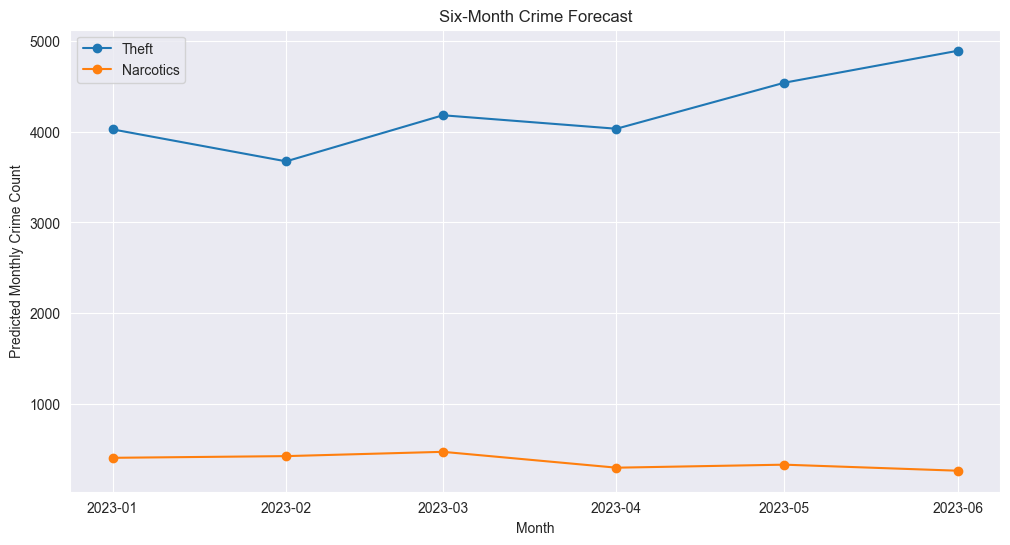

In [134]:
plt.figure(figsize=(12, 6))

plt.plot(
    future_theft.index,
    future_theft,
    marker="o",
    label="Theft"
)

plt.plot(
    future_narcotics.index,
    future_narcotics,
    marker="o",
    label="Narcotics"
)

plt.title("Six-Month Crime Forecast")
plt.xlabel("Month")
plt.ylabel("Predicted Monthly Crime Count")

plt.legend()
plt.grid(True)

plt.show()